In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [38]:
import os
import torch
import torch.optim as optim
import torch.nn as nn
import joblib
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import torch



In [ ]:
%cd /Drive

[Errno 2] No such file or directory: '/Drive'
/content


In [ ]:
%cd /content/drive

/content/drive


In [ ]:
%ls

MyDrive/


In [ ]:
%cd MyDrive

/content/drive/MyDrive


In [ ]:
%ls

'١٨٠ سؤال بالاجابات.gdoc'
 20220617_221828_0000.png
 AAA-Merged.pdf
'AhmedAA (1).pdf'
 AhmedAA.pdf
'Ahmed Abdallah Alrefaey.jpg'
'Ahmed Abdallah Alrefaey.mkv'
 Ahmed-AlrefaeyCV.pdf
 AhmedAlrefaey.pdf
'Ahmed Alrefaey.py'
'Auditing Passwords with a Password Cracking.gdoc'
'A_Z Handwritten Data.csv'
 circuit.ipynb
 Classroom/
'Colab Notebooks'/
 Contract/
'cryptograpy sheet-1 2024.gdoc'
 CV_AhmedA.A.pdf
 cv.n.docx
 CV.pdf
 DC-9/
 deepxorAA.pdf
 documntation1.pdf
 DOS.gdoc
'final project'/
 flight_eticket_A230901051050.pdf
 flight_invoice_A230901051050.pdf
'Front id.pdf'
 gui_edge_detection.fig
 heshaashraf.py
'hesham ashraf.mkv'
'id (1).pdf'
'id (2).pdf'
'id (3).pdf'
 id.pdf
'IMG_20211209_134207 (1).jpg'
 IMG_20211209_134207.jpg
'IMG_20220607_014826 (1).jpg'
 IMG_20220607_014826.jpg
 IMG20220616193428.jpg
 IMG-20230723-WA0004.jpg
 IMG-20230924-WA0197.jpg
'Instance Segmentation for Agricultural Field Monitoring Using YOLOv8.pdf'
 kaggle/
'light intensity using PWM1.pdf'
'Math0_Lecture 2.p

In [ ]:
%cd 'final project'/

/content/drive/MyDrive/final project


In [ ]:
%ls

 1706215.pdf
 Artificial_Intelligence_in_Cybersecurity_Threat_De.pdf
 DataPreprocessingforAIModels.pdf
 final_project/
'Network Intrusion Detection System (1).pdf'


In [ ]:
%cd  flowFeatures.csv

/content/drive/MyDrive/final project/final_project/APT_Detect/data


In [ ]:
%ls

flowFeatures.csv


In [ ]:
# تحميل البيانات
df = pd.read_csv(r"flowFeatures.csv", low_memory=False)
df.columns = df.columns.str.lower()  # توحيد أسماء الأعمدة

# التحقق من وجود العمود 'label'
if 'label' not in df.columns:
    print("🚨 الأعمدة المتاحة:", df.columns.tolist())
    raise KeyError("❌ العمود 'label' غير موجود! تحقق من أسماء الأعمدة.")

# اختيار الأعمدة الرقمية فقط
numeric_columns = df.select_dtypes(include=['number']).columns.tolist()
if 'label' in numeric_columns:
    numeric_columns.remove('label')

X = df[numeric_columns].copy()
y = df['label']

# التعامل مع القيم غير الصالحة
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.median(), inplace=True)

# تحويل الهدف إلى أرقام
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

print("✅ البيانات جاهزة!")


✅ البيانات جاهزة!


In [ ]:
# تقسيم البيانات إلى تدريب واختبار وتحقيق
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# تطبيع البيانات
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("✅ تقسيم البيانات بنجاح!")


✅ تقسيم البيانات بنجاح!


In [ ]:
# تحديد الجهاز المناسب
device = "cuda" if torch.cuda.is_available() else "cpu"

# تحويل البيانات إلى Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)
y_val_tensor = torch.tensor(y_val, dtype=torch.long).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)

# إنشاء DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("✅ البيانات جاهزة للاستخدام مع PyTorch!")


✅ البيانات جاهزة للاستخدام مع PyTorch!


In [ ]:
class APT_Detection_Model(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.lstm = nn.LSTM(input_size, 128, batch_first=True, bidirectional=True)
        self.batch_norm = nn.BatchNorm1d(256)
        self.fc = nn.Sequential(
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x, _ = self.lstm(x.unsqueeze(1))
        x = self.batch_norm(x[:, -1, :])
        return self.fc(x)

# إنشاء النموذج
input_size = X_train.shape[1]
num_classes = len(np.unique(y_train))
model = APT_Detection_Model(input_size, num_classes).to(device)

print("✅ تم إنشاء النموذج!")


✅ تم إنشاء النموذج!


In [ ]:
# تحديد الخسارة والمُحسّن
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)  # تقليل lr كل 3 epochs

print("✅ تم إعداد التدريب!")


✅ تم إعداد التدريب!


In [ ]:
# وظيفة التدريب مع التحقق
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    model.train()

    for epoch in range(epochs):
        total_loss = 0
        correct, total = 0, 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

        scheduler.step()

        # حساب دقة التحقق
        val_accuracy = evaluate_model(model, val_loader)
        print(f"🟢 Epoch {epoch+1}: Loss = {total_loss / len(train_loader):.4f}, Val Accuracy = {val_accuracy:.2f}%")

# وظيفة تقييم النموذج
def evaluate_model(model, test_loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

    return 100 * correct / total

print("✅ وظائف التدريب جاهزة!")


✅ وظائف التدريب جاهزة!


In [ ]:
train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10)


🟢 Epoch 1: Loss = 0.0089, Val Accuracy = 99.91%
🟢 Epoch 2: Loss = 0.0030, Val Accuracy = 99.93%
🟢 Epoch 3: Loss = 0.0023, Val Accuracy = 99.94%
🟢 Epoch 4: Loss = 0.0015, Val Accuracy = 99.96%
🟢 Epoch 5: Loss = 0.0014, Val Accuracy = 99.96%
🟢 Epoch 6: Loss = 0.0013, Val Accuracy = 99.96%
🟢 Epoch 7: Loss = 0.0010, Val Accuracy = 99.96%
🟢 Epoch 8: Loss = 0.0009, Val Accuracy = 99.96%
🟢 Epoch 9: Loss = 0.0009, Val Accuracy = 99.97%
🟢 Epoch 10: Loss = 0.0008, Val Accuracy = 99.97%


In [39]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    train_losses = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct, total = 0, 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

        scheduler.step()

        # Save training loss
        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Evaluate and save validation accuracy
        val_accuracy = evaluate_model(model, val_loader)
        val_accuracies.append(val_accuracy)

        print(f"🟢 Epoch {epoch+1}: Loss = {avg_loss:.4f}, Val Accuracy = {val_accuracy:.2f}%")

    # After training, plot the results
    plot_training_results(train_losses, val_accuracies)


🟢 Epoch 1: Loss = 0.0026, Val Accuracy = 99.96%
🟢 Epoch 2: Loss = 0.0016, Val Accuracy = 99.97%
🟢 Epoch 3: Loss = 0.0015, Val Accuracy = 99.97%
🟢 Epoch 4: Loss = 0.0014, Val Accuracy = 99.97%
🟢 Epoch 5: Loss = 0.0013, Val Accuracy = 99.97%
🟢 Epoch 6: Loss = 0.0012, Val Accuracy = 99.97%
🟢 Epoch 7: Loss = 0.0013, Val Accuracy = 99.97%
🟢 Epoch 8: Loss = 0.0013, Val Accuracy = 99.97%
🟢 Epoch 9: Loss = 0.0012, Val Accuracy = 99.97%
🟢 Epoch 10: Loss = 0.0012, Val Accuracy = 99.97%


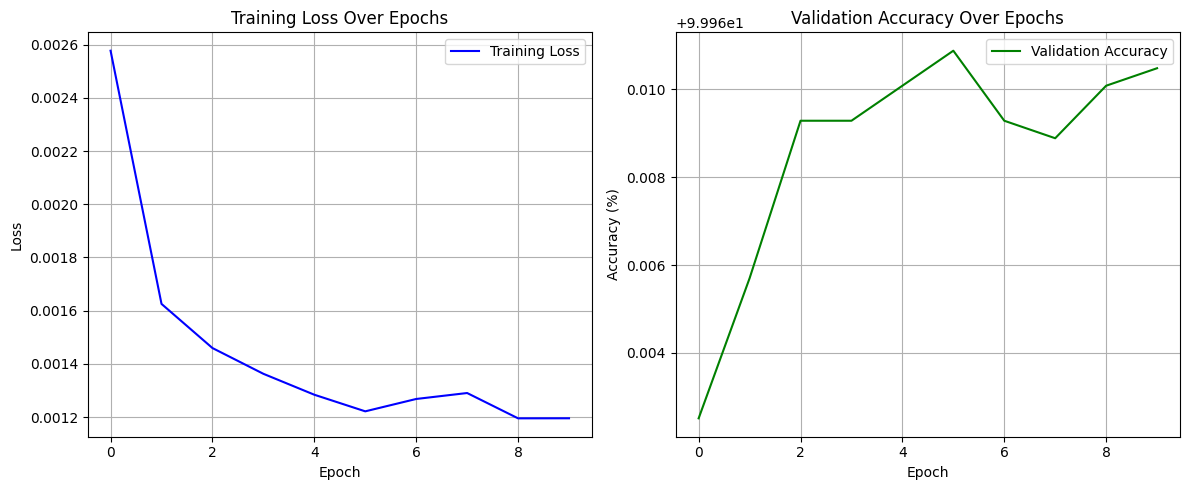

In [ ]:
def plot_training_results(train_losses, val_accuracies):
    plt.figure(figsize=(12, 5))

    # Plot Training Loss
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Training Loss', color='blue')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss Over Epochs')
    plt.grid(True)
    plt.legend()

    # Plot Validation Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(val_accuracies, label='Validation Accuracy', color='green')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Validation Accuracy Over Epochs')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

# 🔁 Now call the training function
train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10)


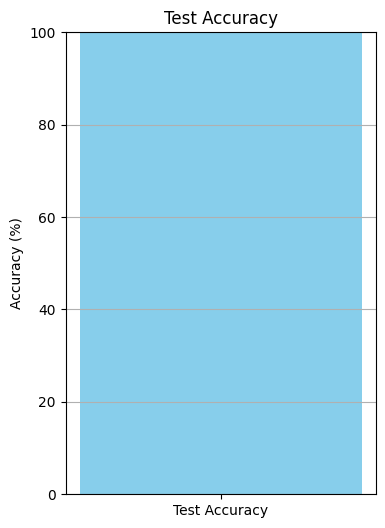

In [34]:
import matplotlib.pyplot as plt

test_accuracy = evaluate_model(model, test_loader)

# Plot accuracy as a bar chart
plt.figure(figsize=(4, 6))
plt.bar(['Test Accuracy'], [test_accuracy * 100], color='skyblue')
plt.ylim(0, 100)
plt.ylabel('Accuracy (%)')
plt.title('Test Accuracy')
plt.grid(axis='y')
plt.show()


In [ ]:
desktop_path = os.path.join(os.path.expanduser("~"), "Desktop")
model_path = os.path.join(desktop_path, "apt_detection_model.pth")
scaler_path = os.path.join(desktop_path, "scaler.pkl")
encoder_path = os.path.join(desktop_path, "label_encoder.pkl")

torch.save({'model_state_dict': model.state_dict(), 'input_size': input_size, 'num_classes': num_classes}, model_path)
joblib.dump(scaler, scaler_path)
joblib.dump(label_encoder, encoder_path)

print(f"✅ النموذج تم حفظه في: {model_path}")


✅ النموذج تم حفظه في: C:\Users\original\Desktop\apt_detection_model.pth


In [ ]:
!pip install flask dash torch numpy joblib pandas plotly


The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


In [ ]:
import os
import torch
import joblib
import numpy as np
import pandas as pd
import logging
from flask import Flask, request, jsonify
from dash import Dash, dcc, html
import plotly.express as px
from flask_cors import CORS  # لدعم الطلبات من متصفحات مختلفة

# إعداد السجل للأخطاء والمعلومات
logging.basicConfig(level=logging.INFO)

# 🔹 تحميل الملفات والتحقق من وجودها
desktop_path = os.path.join(os.path.expanduser("~"), "Desktop")
model_path = os.path.join(desktop_path, "apt_detection_model.pth")
scaler_path = os.path.join(desktop_path, "scaler.pkl")
encoder_path = os.path.join(desktop_path, "label_encoder.pkl")

if not all(os.path.exists(p) for p in [model_path, scaler_path, encoder_path]):
    raise FileNotFoundError("⚠️ تأكد من وجود ملفات النموذج، التهيئة والمحول على سطح المكتب!")

# 🔹 تحميل المكونات المساعدة
scaler = joblib.load(scaler_path)
label_encoder = joblib.load(encoder_path)
input_size = scaler.n_features_in_
num_classes = len(label_encoder.classes_)

# 🔹 تعريف نموذج APT Detection
class APTDetectionModel(torch.nn.Module):
    def __init__(self, input_size, num_classes):
        super(APTDetectionModel, self).__init__()
        self.lstm = torch.nn.LSTM(input_size, 128, num_layers=2, batch_first=True, bidirectional=True)
        self.batch_norm = torch.nn.BatchNorm1d(256)
        self.fc = torch.nn.Sequential(
            torch.nn.Linear(256, 64),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.5),
            torch.nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x, _ = self.lstm(x)
        x = self.batch_norm(x[:, -1, :])
        return self.fc(x)

# 🔹 تحميل النموذج
model = APTDetectionModel(input_size, num_classes)
try:
    with torch.no_grad():  # منع تسجيل التدرجات
        checkpoint = torch.load(model_path, map_location=torch.device('cpu'))
        model.load_state_dict(checkpoint["model_state_dict"], strict=False)
    logging.info("✅ تم تحميل النموذج بنجاح!")
except Exception as e:
    logging.error(f"⚠️ خطأ في تحميل النموذج: {e}")
    raise e

# 🔹 إنشاء تطبيق Flask
app = Flask(__name__)
CORS(app)  # تمكين CORS

# 🔹 صفحة الإدخال
HTML_PAGE = """
<!DOCTYPE html>
<html lang="ar">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>نظام كشف الهجمات</title>
    <style>
        body { font-family: Arial, sans-serif; text-align: center; direction: rtl; background: #f4f4f4; }
        .container { margin-top: 20px; background: white; padding: 20px; border-radius: 10px; box-shadow: 0px 0px 10px rgba(0, 0, 0, 0.1); }
        input { padding: 5px; margin: 5px; width: 80px; text-align: center; }
        button { padding: 10px; background: blue; color: white; border: none; cursor: pointer; margin-top: 10px; }
        .features-grid { display: grid; grid-template-columns: repeat(auto-fill, minmax(100px, 1fr)); gap: 10px; }
        .loading { display: none; font-size: 18px; color: red; margin-top: 10px; }
    </style>
</head>
<body>
    <div class="container">
        <h2>كشف الهجمات</h2>
        <div class="features-grid" id="features-container"></div>
        <button onclick="predict()">توقع</button>
        <p class="loading" id="loading">🔄 جارٍ التوقع...</p>
        <h3 id="result"></h3>
    </div>
    <script>
        let container = document.getElementById('features-container');
        for (let i = 1; i <= 79; i++) {
            let input = document.createElement("input");
            input.type = "text";
            input.placeholder = "ميزة " + i;
            input.id = "feature" + i;
            input.value = (Math.random() * 10).toFixed(2); // قيم افتراضية
            container.appendChild(input);
        }

        function predict() {
            let data = [];
            for (let i = 1; i <= 79; i++) {
                let value = parseFloat(document.getElementById('feature' + i).value);
                data.push(value);
            }
            document.getElementById('loading').style.display = "block";
            fetch('/predict', {
                method: 'POST',
                headers: {'Content-Type': 'application/json'},
                body: JSON.stringify({features: data})
            })
            .then(response => response.json())
            .then(data => {
                document.getElementById('loading').style.display = "none";
                document.getElementById('result').innerText = '🔍 التوقع: ' + data.prediction;
            })
            .catch(error => console.error('Error:', error));
        }
    </script>
</body>
</html>
"""

@app.route('/')
def home():
    return HTML_PAGE

@app.route('/predict', methods=['POST'])
def predict():
    try:
        data = request.json['features']
        if len(data) != input_size:
            return jsonify({'error': 'عدد الميزات غير متطابق مع النموذج!'})

        features = np.array(data).reshape(1, -1)
        features = scaler.transform(features)
        features_tensor = torch.tensor(features, dtype=torch.float32).unsqueeze(1)

        with torch.no_grad():
            output = model(features_tensor)

        prediction = torch.argmax(output, dim=1).item()
        label = label_encoder.inverse_transform([prediction])[0]
        return jsonify({'prediction': label})

    except Exception as e:
        logging.error(f"⚠️ خطأ أثناء التوقع: {e}")
        return jsonify({'error': str(e)})

# 🔹 تشغيل التطبيق
if __name__ == '__main__':
    app.run(debug=False, port=5001)


C:\Users\original\AppData\Local\Temp\ipykernel_23728\2932045676.py:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=torch.d

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5001
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [28/Feb/2025 01:46:55] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [28/Feb/2025 01:51:33] "GET / HTTP/1.1" 200 -
c:\Users\original\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
ERROR:root:⚠️ خطأ أثناء التوقع: Expected more than 1 value per channel when training, got input size torch.Size([1, 256])
INFO:werkzeug:127.0.0.1 - - [28/Feb/2025 01:51:53] "POST /predict HTTP/1.1" 200 -
c:\Users\original\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
ERROR:root:⚠️ خطأ أثناء التوقع: Expected more than 1

In [ ]:
checkpoint = torch.load(model_path, map_location=torch.device('cpu'))
print(checkpoint.keys())  # تحقق مما إذا كان لديك 'model_state_dict'
print(checkpoint['model_state_dict'].keys())  # قائمة الطبقات المخزنة


dict_keys(['model_state_dict', 'input_size', 'num_classes'])
odict_keys(['lstm.weight_ih_l0', 'lstm.weight_hh_l0', 'lstm.bias_ih_l0', 'lstm.bias_hh_l0', 'lstm.weight_ih_l0_reverse', 'lstm.weight_hh_l0_reverse', 'lstm.bias_ih_l0_reverse', 'lstm.bias_hh_l0_reverse', 'batch_norm.weight', 'batch_norm.bias', 'batch_norm.running_mean', 'batch_norm.running_var', 'batch_norm.num_batches_tracked', 'fc.0.weight', 'fc.0.bias', 'fc.3.weight', 'fc.3.bias'])


C:\Users\original\AppData\Local\Temp\ipykernel_20728\3072195463.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=torch.de